In [2]:
import matplotlib.pyplot as plt
import sys

import awkward as ak

import uproot

In [3]:
x_sections = {
                'QCD_PT-120to170': 445800.0,
                'QCD_PT-170to300': 113700.0,
                'QCD_PT-300to470': 7589.0,
                'QCD_PT-470to600': 626.4,
                'QCD_PT-600to800': 178.6,
                'QCD_PT-800to1000': 30.57,
                'QCD_PT-1000to1400': 8.92,
                'QCD_PT-1400to1800': 0.8103,
                'QCD_PT-1800to2400': 0.1148,
                'QCD_PT-2400to3200': 0.007542,
                'QCD_PT-3200': 0.0002331,
                'TTto4Q': 762.1
}

 

def sample_name(name):
    for key in x_sections.keys():
        if key in name:
            return key
    return None

In [4]:
files = []
with open("Run3/qcd_files.txt",'r') as file_list:
    for line in file_list:
        line = line.strip()
        files.append("Run3/mc/QCD/" + line)
        
qcd_mc = {}

for file in files:
    print("Processing " + file + "...")
    name = sample_name(file)
    if name is None:
        continue
    f = uproot.open(file)
    br = f['events'].arrays()

    events = f['cut_flow_hist'].values()[0]
    qcd_mc[name] = {"data": f['events'].arrays(), "weight": [x_sections[name] / events]* len(br['event_HT'])}
    #HT.append([br['event_HT'], [x_sections[name] / events]* len(br['event_HT']),name])
    #highest_PT_jet.append([br['ak4_pt'][:,0], [x_sections[name] / events]* len(br['ak4_pt'][:,0]),name])

Processing Run3/mc/QCD/slimmedNtup_QCD_PT-170to300_TuneCP5_13p6TeV_pythia8_nanogen.root...
Processing Run3/mc/QCD/slimmedNtup_QCD_PT-300to470_TuneCP5_13p6TeV_pythia8_nanogen.root...
Processing Run3/mc/QCD/slimmedNtup_QCD_PT-470to600_TuneCP5_13p6TeV_pythia8_nanogen.root...
Processing Run3/mc/QCD/slimmedNtup_QCD_PT-600to800_TuneCP5_13p6TeV_pythia8_nanogen.root...
Processing Run3/mc/QCD/slimmedNtup_QCD_PT-800to1000_TuneCP5_13p6TeV_pythia8_nanogen.root...
Processing Run3/mc/QCD/slimmedNtup_QCD_PT-1000to1400_TuneCP5_13p6TeV_pythia8_nanogen.root...
Processing Run3/mc/QCD/slimmedNtup_QCD_PT-1400to1800_TuneCP5_13p6TeV_pythia8_nanogen.root...
Processing Run3/mc/QCD/slimmedNtup_QCD_PT-1800to2400_TuneCP5_13p6TeV_pythia8_nanogen.root...
Processing Run3/mc/QCD/slimmedNtup_QCD_PT-2400to3200_TuneCP5_13p6TeV_pythia8_nanogen.root...
Processing Run3/mc/QCD/slimmedNtup_QCD_PT-3200_TuneCP5_13p6TeV_pythia8_nanogen.root...


In [5]:
files = []
with open("Run3/top_files.txt",'r') as file_list:
    for line in file_list:
        line = line.strip()
        files.append("Run3/mc/top/" + line)
        
top_mc = {}

for file in files:
    print("Processing " + file + "...")
    name = sample_name(file)
    if name is None:
        continue
    f = uproot.open(file)
    br = f['events'].arrays()

    events = f['cut_flow_hist'].values()[0]
    top_mc[name] = {"data": f['events'].arrays(), "weight": [x_sections[name] / events]* len(br['event_HT'])}
    #HT.append([br['event_HT'], [x_sections[name] / events]* len(br['event_HT']),name])
    #highest_PT_jet.append([br['ak4_pt'][:,0], [x_sections[name] / events]* len(br['ak4_pt'][:,0]),name])

Processing Run3/mc/top/slimmedNtup_TTto4Q_TuneCP5_13p6TeV_powheg-pythia8.root...


In [6]:
[len(val["weight"]) for val in top_mc.values()]

[83226]

In [6]:
qcd_mc['QCD_PT-170to300']['data'][0]

<Record {Run: 1, Lumi: 1.55e+04, ...} type='{Run: float32, Lumi: float32, E...'>

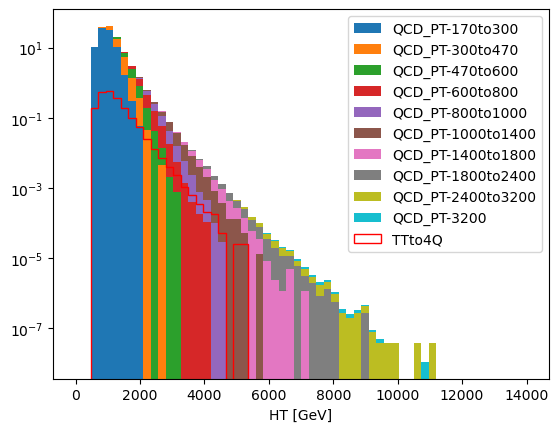

In [7]:
plt.hist(
    [val["data"]["event_HT"] for val in qcd_mc.values()], 
    weights= [val["weight"] for val in qcd_mc.values()], 
    bins= 60,
    stacked=True,
    label=[key for key in qcd_mc.keys()],
    range=(0,14000)
    )

plt.hist(
    [val["data"]["event_HT"] for val in top_mc.values()], 
    weights= [val["weight"] for val in top_mc.values()], 
    bins= 60,
    histtype='step',
    color="red",
    label=[key for key in top_mc.keys()],
    range=(0,14000)
    )

plt.xlabel("HT [GeV]")
#y axis is in pico-barns, need to multiply by luminosity to get num events
#lum in inverse pico-barns
plt.yscale('log')

plt.legend()

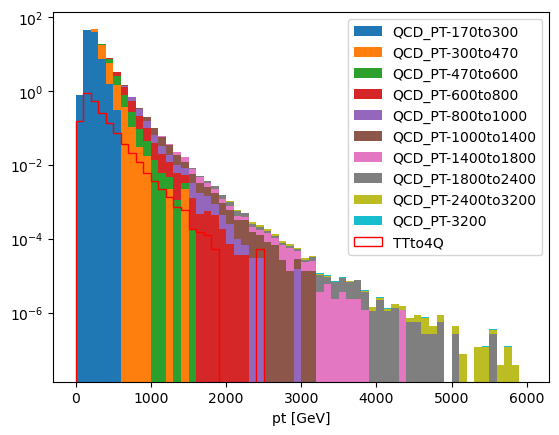

In [8]:
plt.hist(
    [val["data"]['ak4_pt'][:,0] for val in qcd_mc.values()],
    weights= [val["weight"] for val in qcd_mc.values()], 
    bins= 60,
    stacked=True,
    label=[key for key in qcd_mc.keys()],
    range=(0,6000)
    )
plt.hist(
    [val["data"]["ak4_pt"][:,0] for val in top_mc.values()], 
    weights= [val["weight"] for val in top_mc.values()], 
    bins= 60,
    histtype='step',
    color="red",
    label=[key for key in top_mc.keys()],
    range=(0,6000)
    )
plt.xlabel("pt [GeV]")

#y axis is in pico-barns, need to multiply by luminosity to get num events
#lum in inverse pico-barns
plt.yscale('log')
plt.legend()

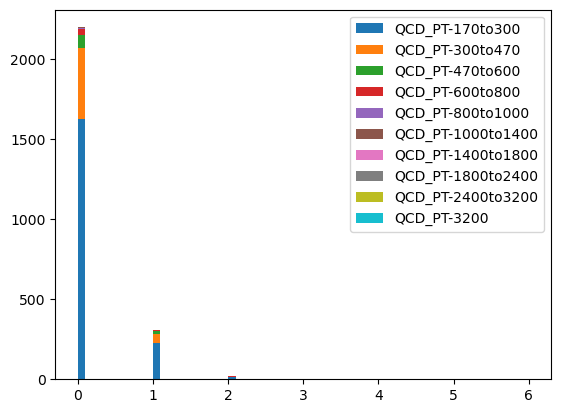

In [9]:
plt.hist(
    [ak.flatten(val["data"]['jtrip_qgl']) for val in qcd_mc.values()],
    weights= [[val["weight"][0]]*len(ak.flatten(val["data"]['jtrip_qgl'])) for val in qcd_mc.values()], 
    bins= 60,
    stacked=True,
    label=[key for key in qcd_mc.keys()],
    range=(0,6)
    )

#y axis is in pico-barns, need to multiply by luminosity to get num events
#lum in inverse pico-barns
plt.legend()

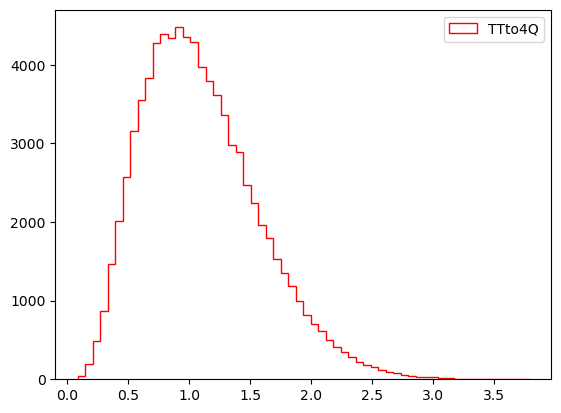

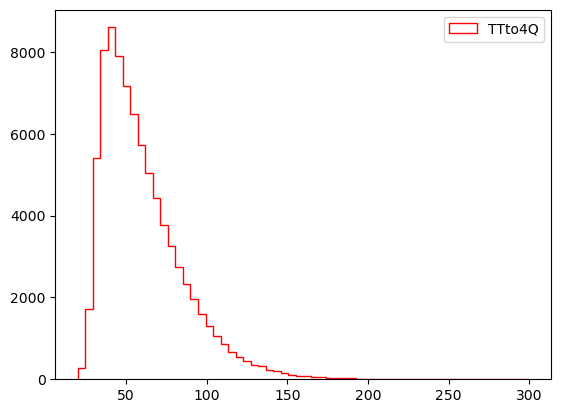

In [46]:
for key in ["jmds6332","sixpt"]:
    plt.hist(
        [val["data"][key] for val in top_mc.values()], 
        #weights= [[val["weight"][0]]*len(ak.flatten(val["data"]['jtrip_qgl'])) for val in top_mc.values()], 
        bins= 60,
        histtype='step',
        color="red",
        label=[key for key in top_mc.keys()],
    )

    #plt.yscale('log')
    plt.legend()
    plt.show()

In [22]:
top_mc['TTto4Q']["data"]["jtrip_mass"]

<Array [1.06e+03, 200, 963, 531, ..., 634, 817, 563, 771] type='20 * float32'>

In [33]:
top_mask = top_mc['TTto4Q']["data"].mask[top_mc['TTto4Q']["data"].jtrip_masym <0.01]
top_mask.jtrip_mass

<Array [[None, None, ..., None, None], ...] type='83226 * var * option[var ...'>

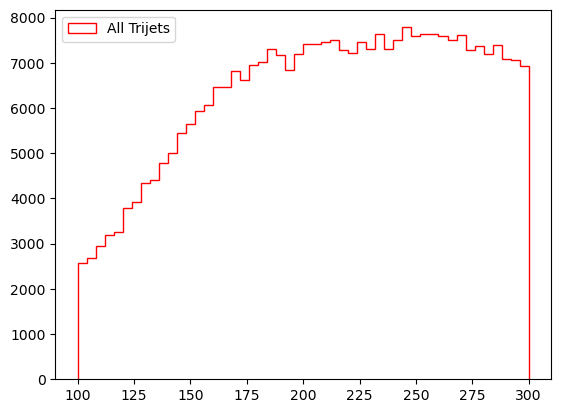

In [34]:


plt.hist(
    ak.flatten(ak.flatten(ak.drop_none(top_mask.jtrip_mass))), 
    #[val["data"]["jtrip_mass"][:,0]  for val in top_mc.values()],
    #weights= [[val["weight"][0]]*len(ak.flatten(val["data"]['jtrip_qgl'])) for val in top_mc.values()], 
    bins= 50,
    histtype='step',
    color="red",
    label="All Trijets",
    range=(100,300)
    )
# plt.hist(
#     #[ak.flatten(val["data"]["jtrip_mass"]) for val in top_mc.values()], 
#     [val["data"]["jtrip_mass"][:,0]  for val in top_mc.values()],
#     #weights= [[val["weight"][0]]*len(ak.flatten(val["data"]['jtrip_qgl'])) for val in top_mc.values()], 
#     bins= 60,
#     histtype='step',
#     color="blue",
#     label="0th element",
#     range=(0,2000)
#     )

#plt.yscale('log')
plt.legend()

In [9]:
mc = qcd_mc.copy()
mc["TTto4Q"] = top_mc["TTto4Q"]

In [10]:

regions = {
    "reg1": {},
    "reg2": {},
    "reg3": {},
    "top_1" :{},
    "top_2" :{},
    "top_3" :{},
}

# event_HT>550 && sixpt>40 && jmds6332<1.25 && jtrip_masym <0.25 && jtrip_delta>250 && jtrip_mds<0.05
for val,key in zip(qcd_mc.values(),qcd_mc.keys()):
    mask  = val["data"].mask[val["data"].event_HT > 550].mask[val["data"].sixpt > 40].mask[val["data"].jmds6332<1.25].mask[val["data"].jtrip_masym <0.25].mask[val["data"].jtrip_delta>250].mask[val["data"].jtrip_mds<0.05] #.mask[val["data"].jtrip_qgl>1].mask[val["data"].jtrip_qgt>0]
    regions["reg1"][key] = {"jtrip_mass": ak.flatten(ak.flatten(ak.drop_none(mask.jtrip_mass))), "weight": [val["weight"][0]]*len(ak.flatten(ak.flatten(ak.drop_none(mask.jtrip_mass))))}
    mask  = val["data"].mask[val["data"].event_HT > 550].mask[val["data"].sixpt > 50].mask[val["data"].jmds6332<1.25].mask[val["data"].jtrip_masym <0.175].mask[val["data"].jtrip_delta>180].mask[val["data"].jtrip_mds<0.175] #.mask[val["data"].jtrip_qgl>1].mask[val["data"].jtrip_qgt>0]
    regions["reg2"][key] = {"jtrip_mass": ak.flatten(ak.flatten(ak.drop_none(mask.jtrip_mass))), "weight": [val["weight"][0]]*len(ak.flatten(ak.flatten(ak.drop_none(mask.jtrip_mass))))}
    mask  = val["data"].mask[val["data"].event_HT > 550].mask[val["data"].sixpt > 100].mask[val["data"].jmds6332<0.9].mask[val["data"].jtrip_masym <0.15].mask[val["data"].jtrip_delta>150].mask[val["data"].jtrip_mds<0.2] #.mask[val["data"].jtrip_qgl>1].mask[val["data"].jtrip_qgt>0]
    regions["reg3"][key] = {"jtrip_mass": ak.flatten(ak.flatten(ak.drop_none(mask.jtrip_mass))), "weight": [val["weight"][0]]*len(ak.flatten(ak.flatten(ak.drop_none(mask.jtrip_mass))))}

for val,key in zip(top_mc.values(),top_mc.keys()):
    mask  = val["data"].mask[val["data"].event_HT > 550].mask[val["data"].sixpt > 40].mask[val["data"].jmds6332<1.25].mask[val["data"].jtrip_masym <0.25].mask[val["data"].jtrip_delta>250].mask[val["data"].jtrip_mds<0.05] #.mask[val["data"].jtrip_qgl>1].mask[val["data"].jtrip_qgt>0]
    regions["top_1"][key] = {"jtrip_mass": ak.flatten(ak.flatten(ak.drop_none(mask.jtrip_mass))), "weight": [val["weight"][0]]*len(ak.flatten(ak.flatten(ak.drop_none(mask.jtrip_mass))))}
    mask  = val["data"].mask[val["data"].event_HT > 550].mask[val["data"].sixpt > 50].mask[val["data"].jmds6332<1.25].mask[val["data"].jtrip_masym <0.175].mask[val["data"].jtrip_delta>180].mask[val["data"].jtrip_mds<0.175] #.mask[val["data"].jtrip_qgl>1].mask[val["data"].jtrip_qgt>0]
    regions["top_2"][key] = {"jtrip_mass": ak.flatten(ak.flatten(ak.drop_none(mask.jtrip_mass))), "weight": [val["weight"][0]]*len(ak.flatten(ak.flatten(ak.drop_none(mask.jtrip_mass))))}
    mask  = val["data"].mask[val["data"].event_HT > 550].mask[val["data"].sixpt > 100].mask[val["data"].jmds6332<0.9].mask[val["data"].jtrip_masym <0.15].mask[val["data"].jtrip_delta>150].mask[val["data"].jtrip_mds<0.2] #.mask[val["data"].jtrip_qgl>1].mask[val["data"].jtrip_qgt>0]
    regions["top_3"][key] = {"jtrip_mass": ak.flatten(ak.flatten(ak.drop_none(mask.jtrip_mass))), "weight": [val["weight"][0]]*len(ak.flatten(ak.flatten(ak.drop_none(mask.jtrip_mass))))}

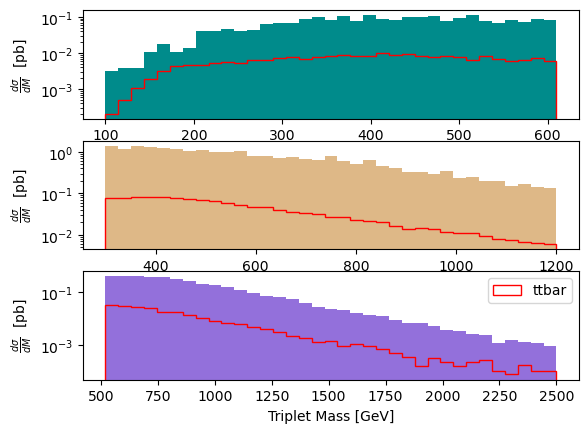

In [11]:

fig,(ax1,ax2,ax3) = plt.subplots(3)

ax1.hist(
    [val["jtrip_mass"] for val in regions["reg1"].values()],
    weights= [val["weight"] for val in regions["reg1"].values()], 
    bins= 35,
    stacked=True,
    histtype='stepfilled',
    color=["darkcyan"]*len(regions["reg1"].values()),
    #label="region 1",
    range=(100,610)
    )
ax1.hist(
    [val["jtrip_mass"] for val in regions["top_1"].values()],
    weights= [val["weight"] for val in regions["top_1"].values()], 
    bins= 35,
    histtype='step',
    color=["red"]*len(regions["top_1"].values()),
    label="ttbar",
    range=(100,610)
    )
ax2.hist(
    [val["jtrip_mass"] for val in regions["reg2"].values()],
    weights= [val["weight"] for val in regions["reg2"].values()], 
    bins= 35,
    stacked=True,
    histtype='stepfilled',
    color=["burlywood"]*len(regions["reg2"].values()),
    #label="region 2",
    range=(300,1200)
    )
ax2.hist(
    [val["jtrip_mass"] for val in regions["top_2"].values()],
    weights= [val["weight"] for val in regions["top_2"].values()], 
    bins= 35,
    histtype='step',
    color=["red"]*len(regions["top_2"].values()),
    range=(300,1200)
    )
ax3.hist(
    [val["jtrip_mass"] for val in regions["reg3"].values()],
    weights= [val["weight"] for val in regions["reg3"].values()], 
    bins= 35,
    stacked=True,
    histtype='stepfilled',
    color=["mediumpurple"]*len(regions["reg3"].values()),
    #label="region 3",
    range=(520,2500)
    )
ax3.hist(
    [val["jtrip_mass"] for val in regions["top_3"].values()],
    weights= [val["weight"] for val in regions["top_3"].values()], 
    bins= 35,
    histtype='step',
    color=["red"]*len(regions["top_3"].values()),
    label="ttbar",
    range=(520,2500)
    )
plt.xlabel("Triplet Mass [GeV]")
ax3.legend()
ax1.set(ylabel = r"$\frac{d\sigma}{dM}$  [pb]")
ax2.set(ylabel = r"$\frac{d\sigma}{dM}$  [pb]")
ax3.set(ylabel = r"$\frac{d\sigma}{dM}$  [pb]")

#y axis is in pico-barns, need to multiply by luminosity to get num events
#lum in inverse pico-barns
ax1.set_yscale("log")
ax2.set_yscale("log")
ax3.set_yscale("log")